

*   558385 - Alexia Ramalho
*   557943 - Enzo Real
*   555454 - Gustavo Pasquini
*   559008 - Hellen Silva
*   557397 - Lorenzo Acquesta






Classificação de participação paternal nos estudos com base no desempenho escolar, Modelo Classificatório

Dataset Escolhido Classificação -> https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis

Dataset Escolhido Regressão -> https://www.kaggle.com/datasets/mikhail1681/walmart-sales/data

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
# pegar os dados diretamente do kaggle pelo kagglehub

data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "grandmaster07/student-exam-performance-dataset-analysis",
  "StudentPerformanceFactors.csv",
)

/tmp/ipykernel_18390/1526809017.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  data = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-exam-performance-dataset-analysis' dataset.


In [ ]:
data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [ ]:
data.columns = data.columns.str.lower()
data.head()

,hours_studied,attendance,parental_involvement,access_to_resources,extracurricular_activities,sleep_hours,previous_scores,motivation_level,internet_access,tutoring_sessions,family_income,teacher_quality,school_type,peer_influence,physical_activity,learning_disabilities,parental_education_level,distance_from_home,gender,exam_score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
for data_col in data.columns:
  print(data[data_col].unique())

[23 19 24 29 25 17 21  9 10 14 22 15 12 20 11 13 16 18 31  8 26 28  4 35
 27 33 36 43 34  1 30  7 32  6 38  5  3  2 39 37 44]
[ 84  64  98  89  92  88  78  94  80  97  83  82  68  60  70  75  99  74
  65  62  91  90  66  69  72  63  61  86  77  71  67  87  73  96 100  81
  95  79  85  76  93]
['Low' 'Medium' 'High']
['High' 'Medium' 'Low']
['No' 'Yes']
[ 7  8  6 10  9  5  4]
[ 73  59  91  98  65  89  68  50  80  71  88  87  97  72  74  70  82  58
  99  84 100  75  54  90  94  51  57  66  96  93  56  52  63  79  81  69
  95  60  92  77  62  85  78  64  76  55  86  61  53  83  67]
['Low' 'Medium' 'High']
['Yes' 'No']
[0 2 1 3 4 5 6 7 8]
['Low' 'Medium' 'High']
['Medium' 'High' 'Low' nan]
['Public' 'Private']
['Positive' 'Negative' 'Neutral']
[3 4 2 1 5 0 6]
['No' 'Yes']
['High School' 'College' 'Postgraduate' nan]
['Near' 'Moderate' 'Far' nan]
['Male' 'Female']
[ 67  61  74  71  70  66  69  72  68  65  64  60  63  62 100  76  79  73
  78  89  75  59  86  97  83  84  80  58  94  55  92  8

In [ ]:
# Segui por essa abordagem, pois ao normalizar os dados em índice (0 à 1) a acurácia e resultados nos testes foi pior
# Criando um mapeamento ordinal para a variável alvo
low_med_hi_map = {'Low': -1, 'Medium': 0, 'High': 1}
yes_no_map = {'Yes': 1, 'No': -1}
public_private_map = {'Public': 0, 'Private': 1}
positive_negative_neutral_map = {'Positive': 1, 'Negative': -1, 'Neutral': 0}
highschool_college_postgraduate_map = {'High School': 0, 'College': 1, 'Postgraduate': 2}
near_moderate_far_map = {'Near': 1, 'Moderate': 0, 'Far': -1}
male_female_map = {'Male': 1, 'Female': 0}

for col in data.columns:
  if data[col][0] in low_med_hi_map:
    data[col] = data[col].map(low_med_hi_map)
  elif data[col][0] in yes_no_map:
    data[col] = data[col].map(yes_no_map)
  elif data[col][0] in public_private_map:
    data[col] = data[col].map(public_private_map)
  elif data[col][0] in positive_negative_neutral_map:
    data[col] = data[col].map(positive_negative_neutral_map)
  elif data[col][0] in highschool_college_postgraduate_map:
    data[col] = data[col].map(highschool_college_postgraduate_map)
  elif data[col][0] in near_moderate_far_map:
    data[col] = data[col].map(near_moderate_far_map)
  elif data[col][0] in male_female_map:
    data[col] = data[col].map(male_female_map)
  else:
    print(f"Coluna não mapeada: {col}")

  print(data[col].unique())

Coluna não mapeada: hours_studied
[23 19 24 29 25 17 21  9 10 14 22 15 12 20 11 13 16 18 31  8 26 28  4 35
 27 33 36 43 34  1 30  7 32  6 38  5  3  2 39 37 44]
Coluna não mapeada: attendance
[ 84  64  98  89  92  88  78  94  80  97  83  82  68  60  70  75  99  74
  65  62  91  90  66  69  72  63  61  86  77  71  67  87  73  96 100  81
  95  79  85  76  93]
[-1  0  1]
[ 1  0 -1]
[-1  1]
Coluna não mapeada: sleep_hours
[ 7  8  6 10  9  5  4]
Coluna não mapeada: previous_scores
[ 73  59  91  98  65  89  68  50  80  71  88  87  97  72  74  70  82  58
  99  84 100  75  54  90  94  51  57  66  96  93  56  52  63  79  81  69
  95  60  92  77  62  85  78  64  76  55  86  61  53  83  67]
[-1  0  1]
[ 1 -1]
Coluna não mapeada: tutoring_sessions
[0 2 1 3 4 5 6 7 8]
[-1  0  1]
[ 0.  1. -1. nan]
[0 1]
[ 1 -1  0]
Coluna não mapeada: physical_activity
[3 4 2 1 5 0 6]
[-1  1]
[ 0.  1.  2. nan]
[ 1.  0. -1. nan]
[1 0]
Coluna não mapeada: exam_score
[ 67  61  74  71  70  66  69  72  68  65  64  60  63  

In [ ]:
# Identificando outras colunas categóricas (exceto o alvo)
# Removed the redundant re-mapping of parental_involvement as it was already mapped in cell 0w1dlJwA7Fn6

cat_cols = data.select_dtypes(include=['object']).columns

# Applying get_dummies only to the remaining categorical features
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)

X = data_encoded.drop('parental_involvement', axis=1)
y = data_encoded['parental_involvement']

# Verificar se há valores nulos após o mapeamento e remover se necessário
# Assuming fillna(0) for X and y is desired behavior for missing values
X = X.fillna(0)
y = y.fillna(0)

display(X.head())

,hours_studied,attendance,access_to_resources,extracurricular_activities,sleep_hours,previous_scores,motivation_level,internet_access,tutoring_sessions,family_income,teacher_quality,school_type,peer_influence,physical_activity,learning_disabilities,parental_education_level,distance_from_home,gender,exam_score
0,23,84,1,-1,7,73,-1,1,0,-1,0.0,0,1,3,-1,0.0,1.0,1,67
1,19,64,0,-1,8,59,-1,1,2,0,0.0,0,-1,4,-1,1.0,0.0,0,61
2,24,98,0,1,7,91,0,1,2,0,0.0,0,0,4,-1,2.0,1.0,1,74
3,29,89,0,1,8,98,0,1,1,0,0.0,0,-1,4,-1,0.0,0.0,1,71
4,19,92,0,1,6,65,0,1,3,0,1.0,0,0,4,-1,1.0,1.0,0,70


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Separação de dados para treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Adicionado o max_iter, estava dando erro de max iterations exceeded
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
# Fazendo predições com o modelo
y_pred = model.predict(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8502269288956127

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.98      0.78      0.87       270
           0       0.78      0.97      0.87       662
           1       0.94      0.69      0.80       390

    accuracy                           0.85      1322
   macro avg       0.90      0.81      0.84      1322
weighted avg       0.87      0.85      0.85      1322



In [ ]:
print(data.shape)
print(data_encoded.shape)

print(len(X), len(y))
print(X.index.equals(y.index))

(6607, 20)
(6607, 20)
6607 6607
True


Using Colab cache for faster access to the 'walmart-sales' dataset.

Métricas de Avaliação (Dados Reais - Walmart Sales):
MAE: 96210.42
MSE: 23979990352.59
RMSE: 154854.74
R² Score: 0.93
R2 treino: 0.9277490764265035
R2 teste: 0.9255637107614703


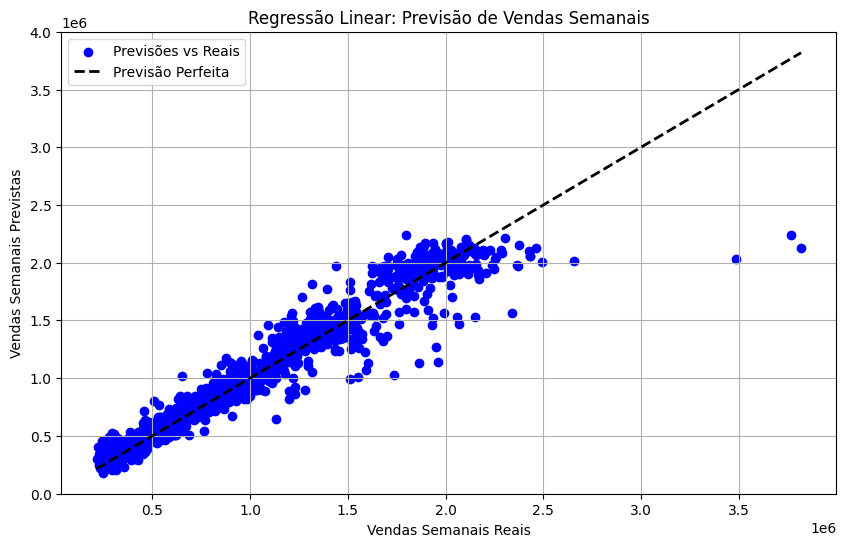

In [ ]:
# Título da seção: Regressão
# Este bloco de código realiza um modelo de regressão linear para prever vendas semanais.

# Baixando a versão mais recente do dataset do Walmart
path = kagglehub.dataset_download("mikhail1681/walmart-sales")

# Definindo o caminho completo para o CSV
walmart_csv_path = os.path.join(path, 'Walmart_Sales.csv')

# Carrega o dataset de vendas do Walmart a partir de um arquivo CSV
data_regression = pd.read_csv(walmart_csv_path)

# Converte a coluna 'Date' para o formato datetime, especificando o formato original
# Isso é crucial para que o Pandas interprete corretamente as datas (dia-mês-ano)
data_regression['Date'] = pd.to_datetime(data_regression['Date'], format='%d-%m-%Y')

# Extrai o mês da data e cria uma nova coluna 'Month'
data_regression['Month'] = data_regression['Date'].dt.month
# Extrai a semana do ano e cria uma nova coluna 'Week'
data_regression['Week'] = data_regression['Date'].dt.isocalendar().week
# Extrai o ano da data e cria uma nova coluna 'Year'
data_regression['Year'] = data_regression['Date'].dt.year


# Define as variáveis independentes (features) que serão usadas para a predição
X = data_regression[['Store', 'Month', 'Week', 'Year',
        'Temperature', 'Fuel_Price', 'CPI',
        'Unemployment', 'Holiday_Flag']]

# Converte a coluna 'Store' (que é categórica) em variáveis dummy usando one-hot encoding
# `drop_first=True` evita a multicolinearidade, removendo a primeira categoria
X = pd.get_dummies(X, columns=['Store'], drop_first=True)
# Define a variável dependente (target) que queremos prever: 'Weekly_Sales'
y = data_regression['Weekly_Sales']

# 2. Separação de dados para treinamento e teste
# Divide os dados em conjuntos de treinamento (80%) e teste (20%)
# `random_state` garante a reprodutibilidade da divisão
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Treina um modelo de regressão linear
# Inicializa o modelo de Regressão Linear
model = LinearRegression()
# Ajusta o modelo aos dados de treinamento (X_train e y_train)
model.fit(X_train, y_train)

# 4. Avalia o modelo
# Realiza previsões no conjunto de teste (X_test)
y_pred = model.predict(X_test)

# Calcula o Erro Médio Absoluto (MAE)
mae = mean_absolute_error(y_test, y_pred)
# Calcula o Erro Quadrático Médio (MSE)
mse = mean_squared_error(y_test, y_pred)
# Calcula a Raiz do Erro Quadrático Médio (RMSE)
rmse = np.sqrt(mse)
# Calcula o Coeficiente de Determinação (R² Score)
r2 = r2_score(y_test, y_pred)

# Imprime as métricas de avaliação do modelo
print(f"\nMétricas de Avaliação (Dados Reais - Walmart Sales):")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# Imprime o R² score para os dados de treinamento e teste para verificar overfitting
print("R2 treino:", model.score(X_train, y_train))
print("R2 teste:", model.score(X_test, y_test))

# 5. Plotar o resultado
# Cria uma figura para o gráfico com tamanho definido
plt.figure(figsize=(10, 6))
# Plota um gráfico de dispersão comparando os valores reais (y_test) com os valores previstos (y_pred)
plt.scatter(y_test, y_pred, color='blue', label='Previsões vs Reais')
# Adiciona uma linha tracejada preta que representa a previsão perfeita (onde y_test == y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Previsão Perfeita')
# Define o rótulo do eixo X
plt.xlabel('Vendas Semanais Reais')
# Define o rótulo do eixo Y
plt.ylabel('Vendas Semanais Previstas')
# Define o título do gráfico
plt.title('Regressão Linear: Previsão de Vendas Semanais')
# Exibe a legenda
plt.legend()
# Adiciona uma grade ao gráfico
plt.grid(True)
# Mostra o gráfico
plt.show()

In [ ]:
data_regression

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Week,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,5,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,6,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,7,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,8,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,9,2010
...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,9,39,2012
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,10,40,2012
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,10,41,2012
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,10,42,2012
